## Reducing Risk by Diversification - Number of Securities to Hold

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

In [2]:
df = pd.read_csv('../data/15stocks_price.csv')
df['date_gsheets'] = pd.to_datetime(df['date_gsheets'], format='mixed')
df.set_index('date_gsheets', inplace=True)

In [3]:
returns = df.pct_change(1)
returns.dropna(inplace=True)

In [4]:
num_stocks = 15
weights = [1 / num_stocks] * num_stocks
vcv_matrix = returns.cov(ddof=1)

var_p = np.dot(np.transpose(weights),
               np.dot(vcv_matrix, weights))
sd_p = np.sqrt(var_p)
sd_p_annual = sd_p * np.sqrt(250)

individual_risks = returns.std(ddof=1) * np.sqrt(250)

In [5]:
tickers = list(returns.columns)
portfolios = []

for i in range(1, len(tickers) + 1):
    portfolios.append(tickers[0:i])

portfolio_risks = []
for port in portfolios:
    df = returns[port]
    
    num_stocks = len(df.columns)
    weights = [1 / num_stocks] * num_stocks
    vcv_p = df.cov(ddof=1)

    var_p = np.dot(np.transpose(weights),
                  np.dot(vcv_p, weights))
    sd_p = np.sqrt(var_p)
    sd_p_annual = sd_p * np.sqrt(250)

    portfolio_risks.append(sd_p_annual)

<Axes: xlabel='num_securities'>

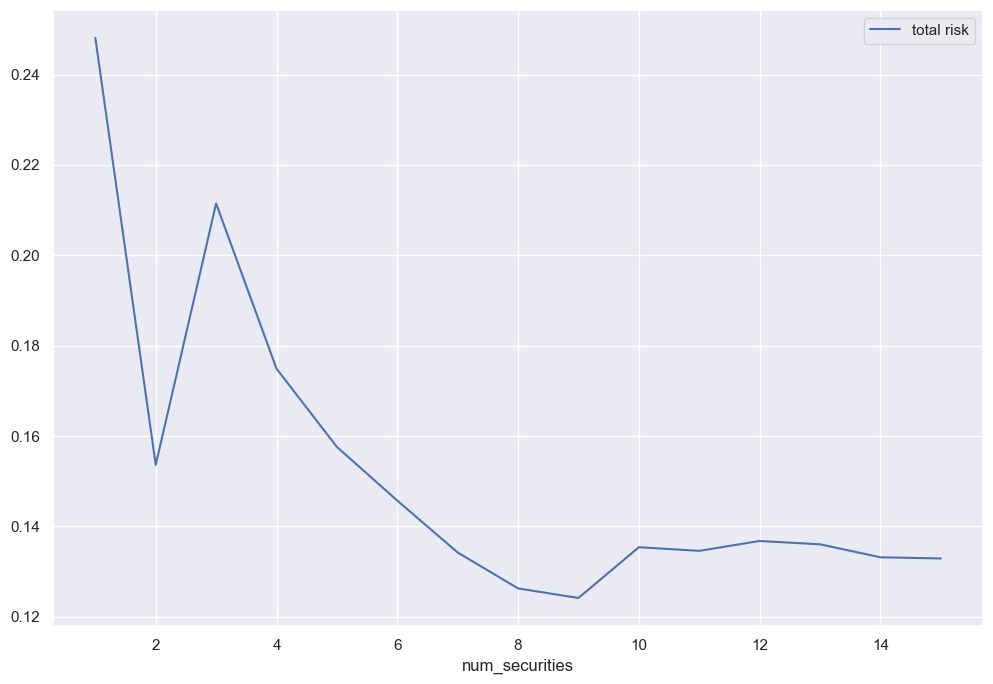

In [8]:
risks_df = pd.DataFrame(portfolio_risks)
risks_df.rename(columns={risks_df.columns[0] : 'total risk'},
               inplace=True)
risks_df.reset_index(inplace=True)
risks_df.rename(columns={'index' : 'num_securities'}, inplace=True)
risks_df['num_securities'] += 1
risks_df.set_index('num_securities', inplace=True)
risks_df.plot(figsize=(12,8))

In [9]:
risks_df

,total risk
num_securities,
1,0.248085
2,0.153617
3,0.211457
4,0.174917
5,0.157592
6,0.145713
7,0.134229
8,0.126281
9,0.124166


## Let's study Berkshire Hathaway Portfolio

In [10]:
brk_portfolio = pd.read_csv('../data/brk_portfolio.csv')

In [12]:
sorted_by_weights = brk_portfolio.sort_values(by='weights',
                                             ascending=False)

In [14]:
sorted_by_weights['cumulative_weights'] = sorted_by_weights['weights'].cumsum()

In [15]:
sorted_by_weights

,company,symbol,holdings,mkt_price,value,weights,cumulative_weights
1,Apple Inc.,AAPL,249589329,235.28,5.872338e+10,0.267314,0.267314
5,Bank of America Corp,BAC,947760000,30.26,2.867922e+10,0.130550,0.397864
16,Coca-Cola Co,KO,400000000,53.79,2.151600e+10,0.097943,0.495807
44,Wells Fargo & Co,WFC,409803773,49.61,2.033037e+10,0.092546,0.588352
3,American Express Company,AXP,151610700,119.10,1.805683e+10,0.082196,0.670548
15,Kraft Heinz Co,KHC,325634818,27.77,9.042879e+09,0.041164,0.711712
41,U.S. Bancorp,USB,132459618,54.71,7.246866e+09,0.032988,0.744701
14,JPMorgan Chase & Co.,JPM,59514932,120.35,7.162622e+09,0.032605,0.777306
25,Moody's Corporation,MCO,24669778,218.77,5.397007e+09,0.024568,0.801873
12,Goldman Sachs Group Inc,GS,18353635,206.46,3.789291e+09,0.017249,0.819122


In [ ]:
# it invests most of its money in 15 to 20 stocks